[*********************100%***********************]  4 of 4 completed



--- ETF COMPARISON SUMMARY ---
        Annual Return  Annual Volatility  Sharpe Ratio  Max Drawdown
Ticker                                                              
XLK            0.2025             0.2479        0.6554       -0.3356
QQQ            0.1661             0.2242        0.5625       -0.3512
SPY            0.1360             0.1709        0.5621       -0.2450
XLF            0.1075             0.1867        0.3616       -0.2581


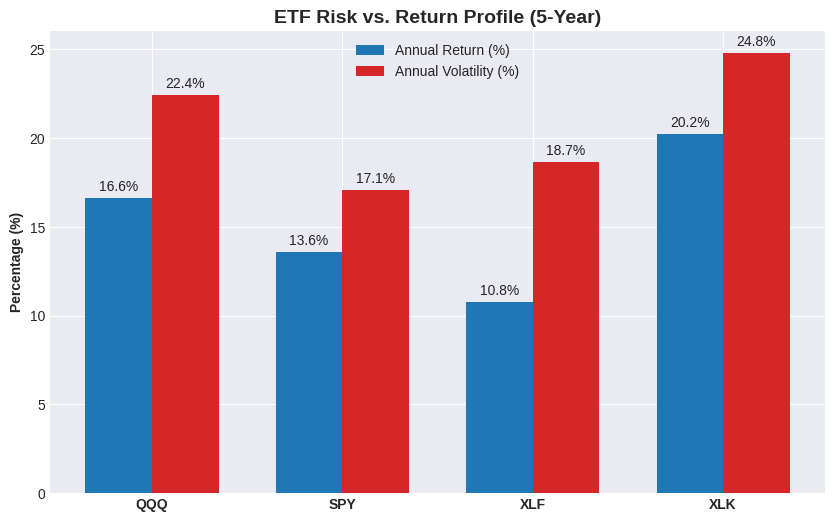

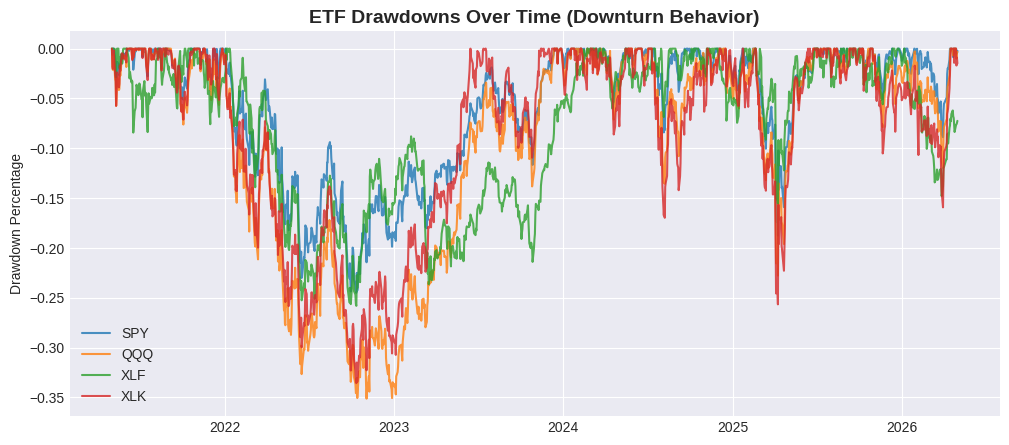

In [2]:
# Project 2: ETF Sector Comparison
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Define ETFs
tickers = ['SPY', 'QQQ', 'XLF', 'XLK']
print(f"Downloading data for: {', '.join(tickers)}...")
data = yf.download(tickers, period='5y')['Close']

# 2. Calculate Returns and Risk Metrics
daily_returns = data.pct_change().dropna()

# Annualized Metrics
annual_return = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)
sharpe_ratio = (annual_return - 0.04) / annual_volatility

# Maximum Drawdown (Downturn Behavior)
cumulative_returns = (1 + daily_returns).cumprod()
peak = cumulative_returns.cummax()
drawdown = (cumulative_returns - peak) / peak
max_drawdown = drawdown.min()

# Compile Results
results = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown': max_drawdown
}).round(4)

print("\n--- ETF COMPARISON SUMMARY ---")
print(results.sort_values(by='Sharpe Ratio', ascending=False))

# 3. Visual Comparisons
plt.style.use('seaborn-v0_8-darkgrid')

# Chart A Alternative: Grouped Bar Chart (Return vs. Volatility)
x = np.arange(len(tickers))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
# Multiplying by 100 to display as clean percentages
rects1 = ax.bar(x - width/2, annual_return * 100, width, label='Annual Return (%)', color='#1f77b4')
rects2 = ax.bar(x + width/2, annual_volatility * 100, width, label='Annual Volatility (%)', color='#d62728')

ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_title('ETF Risk vs. Return Profile (5-Year)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(annual_return.index, fontweight='bold')
ax.legend()

# Add exact numbers on top of the bars for maximum clarity
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.show()

# Chart B: Drawdowns (Downturn Behavior)
plt.figure(figsize=(12, 5))
for ticker in tickers:
    plt.plot(drawdown.index, drawdown[ticker], label=ticker, alpha=0.8, linewidth=1.5)
plt.title('ETF Drawdowns Over Time (Downturn Behavior)', fontsize=14, fontweight='bold')
plt.ylabel('Drawdown Percentage')
plt.legend(loc='lower left')
plt.show()